<a href="https://colab.research.google.com/github/hyunkyung31/DeepLearningProject/blob/main/Efficient_CADICA_ADSD/yuri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import urllib.request
import zipfile
dataset_url = "/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/02_dataset/CADICA.zip"
with zipfile.ZipFile("/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/02_dataset/CADICA.zip", "r") as zip_ref:
     zip_ref.extractall("./CADICA")
     print("압축 해제 완료!")

압축 해제 완료!


In [ ]:
dataset_url = "/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/added_data/Stenosis detection.zip"
with zipfile.ZipFile("/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/added_data/Stenosis detection.zip", "r") as zip_ref:
     zip_ref.extractall("./ADSD")
     print("압축 해제 완료!")

압축 해제 완료!


In [ ]:
from pathlib import Path
import pandas as pd
from torch.utils.data import DataLoader
csv_path = "/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/split_csv/common_split.csv"
df = pd.read_csv(csv_path)

base = Path("/content/CADICA/CADICA/selectedVideos")

def expand_to_frames(row):
    v_dir = base / row.patient_id / row.video_id / "input"
    if not v_dir.exists():
        return []
    frame_rows = []
    for png_path in sorted(v_dir.glob("*.png")):
        frame_rows.append({
            "patient_id": row.patient_id,
            "video_id": row.video_id,
            "frame_path": str(png_path),
            "frame_id": png_path.stem,          # 예: p1_v2_00015
            "label": row.label,
            "view": row.view,
            "split": row.split,                  # video의 split을 그대로 물려받음
            "has_groundtruth": row.has_groundtruth,
        })
    return frame_rows

all_frames = []
for _, row in df.iterrows():
    all_frames.extend(expand_to_frames(row))

frame_df = pd.DataFrame(all_frames)
print("총 프레임 수:", len(frame_df))
print(frame_df.split.value_counts())
frame_df.head()

총 프레임 수: 15799
split
train    13316
val       1396
test      1087
Name: count, dtype: int64


,patient_id,video_id,frame_path,frame_id,label,view,split,has_groundtruth
0,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00001,lesion,<bound method Series.view of patient_id ...,train,True
1,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00002,lesion,<bound method Series.view of patient_id ...,train,True
2,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00003,lesion,<bound method Series.view of patient_id ...,train,True
3,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00004,lesion,<bound method Series.view of patient_id ...,train,True
4,p1,v2,/content/CADICA/CADICA/selectedVideos/p1/v2/in...,p1_v2_00005,lesion,<bound method Series.view of patient_id ...,train,True


In [ ]:
print(df.columns)

Index(['patient_id', 'video_id', 'label', 'view', 'n_frames',
       'has_groundtruth', 'split'],
      dtype='object')


In [ ]:
from pathlib import Path
import pandas as pd

# 1. ADSD CSV 로드
csv_path = "/content/drive/MyDrive/바이오메디컬AI/🐥new_2_project/04_DL_project/split_csv/adsd_patient_split.csv"
df = pd.read_csv(csv_path)

# 1. 파일 리스트 로드 (작성하신 코드 유지)
adsd_base = Path("/content/ADSD/dataset")
all_bmp_files = list(adsd_base.glob("*.bmp"))

frame_rows = []
for bmp_path in all_bmp_files:
    file_id = bmp_path.stem
    match = df[df['patient_id'] == file_id]

    label = 0
    split = 'train'
    if not match.empty:
        split = match.iloc[0]['split']

    frame_rows.append({
        "frame_path": str(bmp_path),
        "patient_id": file_id,
        "label": label,
        "split": split,
        "source": "ADSD"
    })

frame_df_adsd = pd.DataFrame(frame_rows)

# 4. 결과 출력 (frame_df_adsd 사용)
print(f"ADSD 총 프레임 수: {len(frame_df_adsd)}")
print(frame_df_adsd['split'].value_counts())
frame_df_adsd.head()

ADSD 총 프레임 수: 8325
split
train    8325
Name: count, dtype: int64


,frame_path,patient_id,label,split,source
0,/content/ADSD/dataset/14_021_30_0019.bmp,14_021_30_0019,0,train,ADSD
1,/content/ADSD/dataset/14_015_1_0057.bmp,14_015_1_0057,0,train,ADSD
2,/content/ADSD/dataset/14_007_8_0098.bmp,14_007_8_0098,0,train,ADSD
3,/content/ADSD/dataset/14_021_6_0017.bmp,14_021_6_0017,0,train,ADSD
4,/content/ADSD/dataset/14_050_9_0043.bmp,14_050_9_0043,0,train,ADSD


In [ ]:
frame_df['source'] = 'CADICA'

total_df = pd.concat([frame_df, frame_df_adsd], ignore_index=True)

print('전체 데이터 수:', len(total_df))
print(total_df.groupby(['source','split']).size())

전체 데이터 수: 24124
source  split
ADSD    train     8325
CADICA  test      1087
        train    13316
        val       1396
dtype: int64


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

class CADICADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['frame_path']).convert('RGB')
        label = 1 if row['label'] == 'lesion' else 0

        if self.transform:
            image = self.transform(image)

        return image, label

transform_train = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import DataLoader

# 1. 데이터셋 분할 (CSV의 split 정보를 활용)
train_df = frame_df[frame_df.split == 'train']
val_df = frame_df[frame_df.split == 'val']
test_df = frame_df[frame_df.split == 'test']

# 2. 데이터셋 인스턴스 생성
train_dataset = CADICADataset(train_df, transform=transform_train)
val_dataset = CADICADataset(val_df, transform=transform_val)
test_dataset = CADICADataset(test_df, transform=transform_val)

# 3. 데이터 로더 생성 (배치 사이즈는 32 정도로 설정)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"검증 데이터 개수: {len(val_dataset)}")

학습 데이터 개수: 13316
검증 데이터 개수: 1396


#EfficientNet-B4

Epoch 1/50, Train Loss: 0.4194, Val Loss: 1.1571
--> Best model saved!
Epoch 2/50, Train Loss: 0.0697, Val Loss: 1.7851
Epoch 3/50, Train Loss: 0.0352, Val Loss: 1.7276
Epoch 4/50, Train Loss: 0.0253, Val Loss: 2.1777
Epoch 5/50, Train Loss: 0.0172, Val Loss: 1.7214
Epoch 6/50, Train Loss: 0.0121, Val Loss: 1.6977
Epoch 7/50, Train Loss: 0.0093, Val Loss: 1.7938
Epoch 8/50, Train Loss: 0.0097, Val Loss: 1.8652
Epoch 9/50, Train Loss: 0.0112, Val Loss: 1.8430
Epoch 10/50, Train Loss: 0.0098, Val Loss: 1.7504
Epoch 11/50, Train Loss: 0.0082, Val Loss: 1.8638
Epoch 12/50, Train Loss: 0.0081, Val Loss: 1.8260
Epoch 13/50, Train Loss: 0.0087, Val Loss: 1.7307
Epoch 14/50, Train Loss: 0.0085, Val Loss: 1.8050
Epoch 15/50, Train Loss: 0.0099, Val Loss: 1.7600
Epoch 16/50, Train Loss: 0.0079, Val Loss: 1.8567
Epoch 17/50, Train Loss: 0.0081, Val Loss: 1.7686
Epoch 18/50, Train Loss: 0.0091, Val Loss: 1.7986
Epoch 19/50, Train Loss: 0.0073, Val Loss: 1.7510
Epoch 20/50, Train Loss: 0.0079, Val 

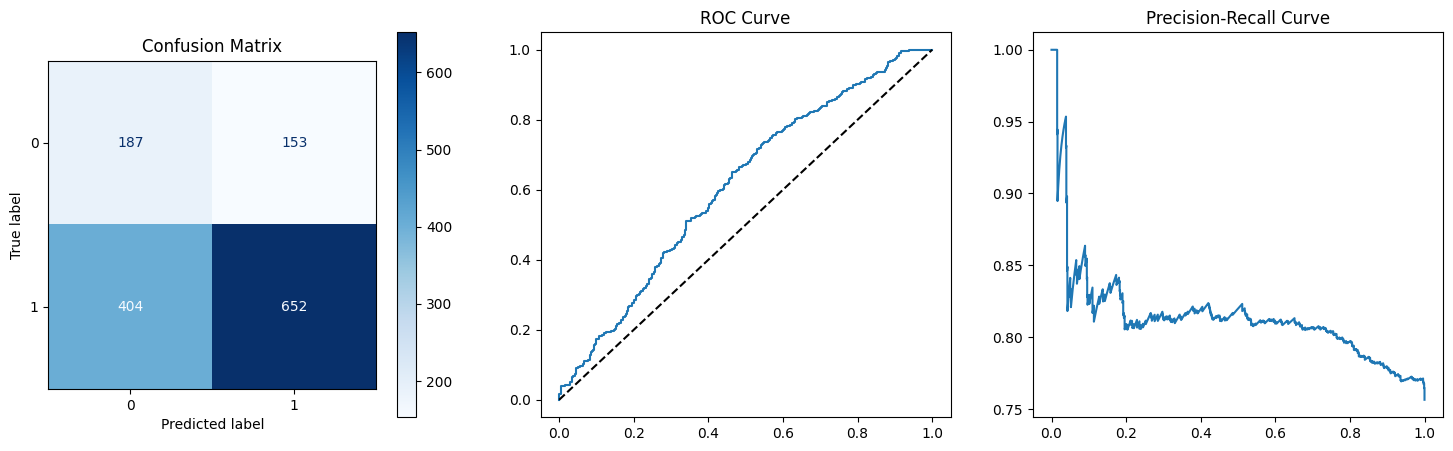

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve

# 1. EfficientNet-B4 모델 설정
# EfficientNet-B4는 380x380 입력 사이즈가 권장됩니다.
model = models.efficientnet_b4(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# 2. 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

# 3. 학습 및 검증 루프
train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_efficientnet_b4.pth')
        print("--> Best model saved!")

    scheduler.step(epoch_val_loss)

# 4. 성능 평가 및 시각화
model.load_state_dict(torch.load('best_efficientnet_b4.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 지표 출력
print(classification_report(all_labels, all_preds, target_names=['Non-lesion', 'Lesion']))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(all_labels, all_probs):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')

prec, rec, _ = precision_recall_curve(all_labels, all_probs)
axes[2].plot(rec, prec)
axes[2].set_title('Precision-Recall Curve')
plt.show()

In [ ]:
# 불균형 해소(Sampler), 과적합 방지(Label Smoothing, Weight, Decay, Early Stopping), 효율적 학습 반영(AdamW, Scheduler)

Epoch 1/50, Train Loss: 0.5471, Val Loss: 0.6340
--> Best model saved!
Epoch 2/50, Train Loss: 0.3594, Val Loss: 0.8938
--> EarlyStopping counter: 1 out of 5
Epoch 3/50, Train Loss: 0.2767, Val Loss: 0.9510
--> EarlyStopping counter: 2 out of 5
Epoch 4/50, Train Loss: 0.2461, Val Loss: 0.8111
--> EarlyStopping counter: 3 out of 5
Epoch 5/50, Train Loss: 0.2332, Val Loss: 0.8829
--> EarlyStopping counter: 4 out of 5
Epoch 6/50, Train Loss: 0.2310, Val Loss: 0.9177
--> EarlyStopping counter: 5 out of 5
Early Stopping triggered!
              precision    recall  f1-score   support

  Non-lesion       0.33      0.28      0.31       340
      Lesion       0.78      0.82      0.80      1056

    accuracy                           0.69      1396
   macro avg       0.56      0.55      0.55      1396
weighted avg       0.67      0.69      0.68      1396



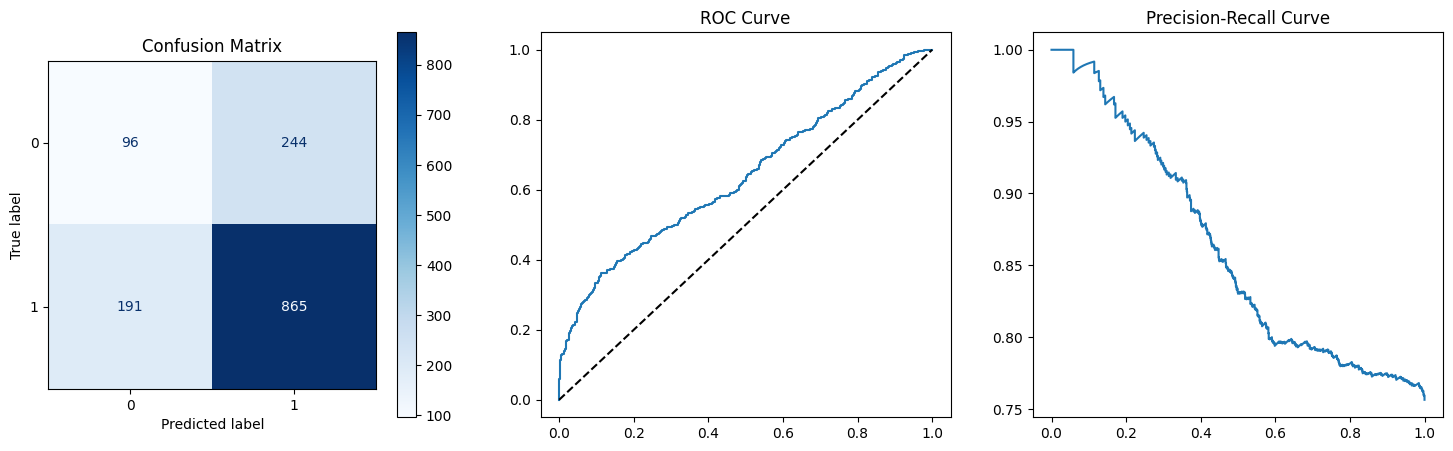

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve

# 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 50
patience = 5  # Early Stopping 설정

# 1. 모델 설정
model = models.efficientnet_b4(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# 2. 손실 함수 및 옵티마이저 (AdamW 사용)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# 3. 학습 루프 (Early Stopping 포함)
train_losses, val_losses = [], []
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

    # 모델 저장 및 Early Stopping 체크
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_efficientnet_b4.pth')
        print("--> Best model saved!")
        counter = 0
    else:
        counter += 1
        print(f"--> EarlyStopping counter: {counter} out of {patience}")
        if counter >= patience:
            print("Early Stopping triggered!")
            break

    scheduler.step(epoch_val_loss)

# 4. 성능 평가 및 시각화
model.load_state_dict(torch.load('best_efficientnet_b4.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 지표 출력
print(classification_report(all_labels, all_preds, target_names=['Non-lesion', 'Lesion']))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(all_labels, all_probs):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')

prec, rec, _ = precision_recall_curve(all_labels, all_probs)
axes[2].plot(rec, prec)
axes[2].set_title('Precision-Recall Curve')
plt.show()

Epoch 1/50, Train Loss: 0.6399, Val Loss: 0.7514
--> Best model saved!
Epoch 2/50, Train Loss: 0.4245, Val Loss: 0.9255
Epoch 3/50, Train Loss: 0.3290, Val Loss: 0.9354
Epoch 4/50, Train Loss: 0.2969, Val Loss: 0.9214
Epoch 5/50, Train Loss: 0.2810, Val Loss: 0.9278
Epoch 6/50, Train Loss: 0.2787, Val Loss: 0.9326
Epoch 7/50, Train Loss: 0.2784, Val Loss: 0.9140
Epoch 8/50, Train Loss: 0.2770, Val Loss: 0.9347
Epoch 9/50, Train Loss: 0.2743, Val Loss: 0.9223
Epoch 10/50, Train Loss: 0.2770, Val Loss: 0.9132
Epoch 11/50, Train Loss: 0.2742, Val Loss: 0.9467
Early Stopping triggered!

--- Classification Report (Threshold: 0.6) ---
              precision    recall  f1-score   support

  Non-lesion       0.35      0.73      0.48       340
      Lesion       0.87      0.57      0.69      1056

    accuracy                           0.61      1396
   macro avg       0.61      0.65      0.58      1396
weighted avg       0.74      0.61      0.64      1396



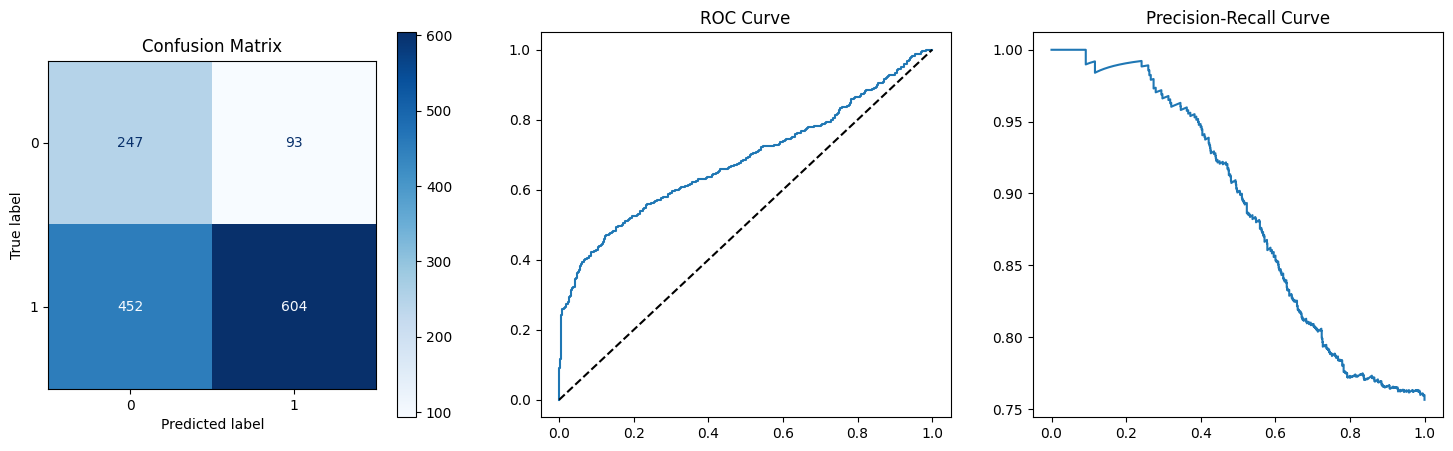

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 50
patience = 10

model = models.efficientnet_b4(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=torch.tensor([2.0, 1.0]).to(device), label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_efficientnet_b4.pth')
        print("--> Best model saved!")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping triggered!")
            break
    scheduler.step(epoch_val_loss)

model.load_state_dict(torch.load('best_efficientnet_b4.pth'))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

threshold = 0.6
all_preds = [1 if p > threshold else 0 for p in all_probs]

print(f"\n--- Classification Report (Threshold: {threshold}) ---")
print(classification_report(all_labels, all_preds, target_names=['Non-lesion', 'Lesion']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(all_labels, all_probs):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
axes[2].plot(rec, prec)
axes[2].set_title('Precision-Recall Curve')
plt.show()

Epoch 1/50, Train Loss: 0.6062, Val Loss: 0.7110
--> Best model saved!
Epoch 2/50, Train Loss: 0.4140, Val Loss: 0.8855
Epoch 3/50, Train Loss: 0.3218, Val Loss: 0.8844
Epoch 4/50, Train Loss: 0.2860, Val Loss: 0.8901
Epoch 5/50, Train Loss: 0.2703, Val Loss: 0.9113
Epoch 6/50, Train Loss: 0.2670, Val Loss: 0.9502
Early Stopping triggered!

--- 최종 평가 결과 (Threshold: 0.55) ---
              precision    recall  f1-score   support

  Non-lesion       0.33      0.66      0.44       340
      Lesion       0.84      0.57      0.68      1056

    accuracy                           0.59      1396
   macro avg       0.58      0.61      0.56      1396
weighted avg       0.71      0.59      0.62      1396



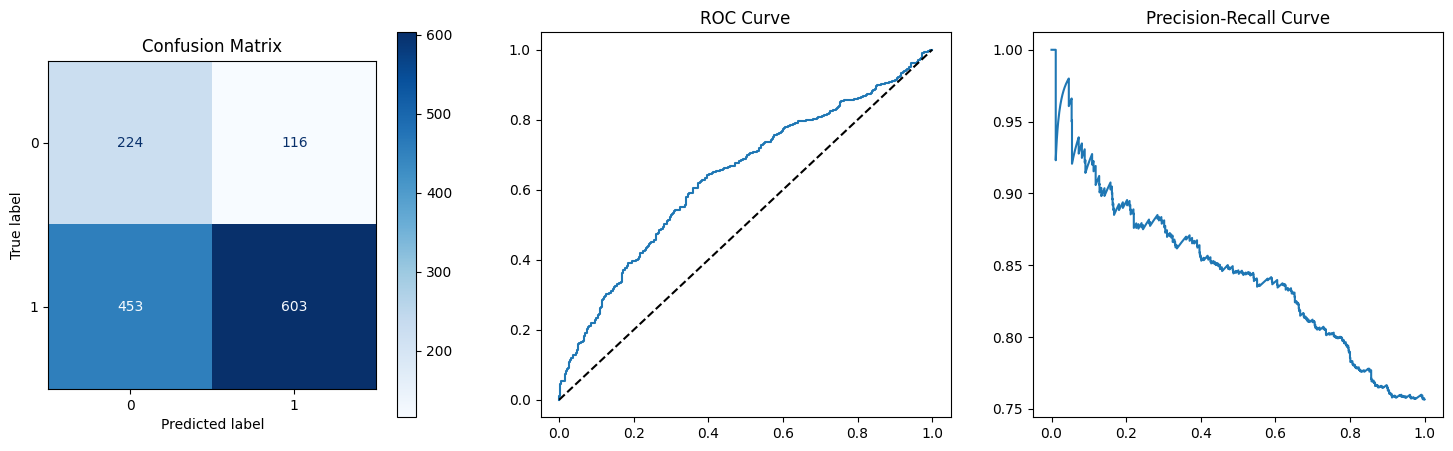

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 50
patience = 5

# 1. 모델 설정
model = models.efficientnet_b4(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# 2. 손실 함수 (가중치 조절: [1.5, 1.0]으로 완화하여 밸런스 조정)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.5, 1.0]).to(device), label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# 3. 학습 루프 (Early Stopping 포함)
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_efficientnet_b4.pth')
        print("--> Best model saved!")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping triggered!")
            break
    scheduler.step(epoch_val_loss)

# 4. 성능 평가 (임계값 0.55 적용)
model.load_state_dict(torch.load('best_efficientnet_b4.pth'))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 임계값 조정: 0.55로 설정하여 정상/병변 분류 균형 도모
threshold = 0.55
all_preds = [1 if p > threshold else 0 for p in all_probs]

# 지표 출력
print(f"\n--- 최종 평가 결과 (Threshold: {threshold}) ---")
print(classification_report(all_labels, all_preds, target_names=['Non-lesion', 'Lesion']))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(all_labels, all_probs):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
axes[2].plot(rec, prec)
axes[2].set_title('Precision-Recall Curve')
plt.show()

In [ ]:

!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 124.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=0637d14ea9f42448a804405f46a001dd672fba70f6c23ee37206e4401f61b9ce
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


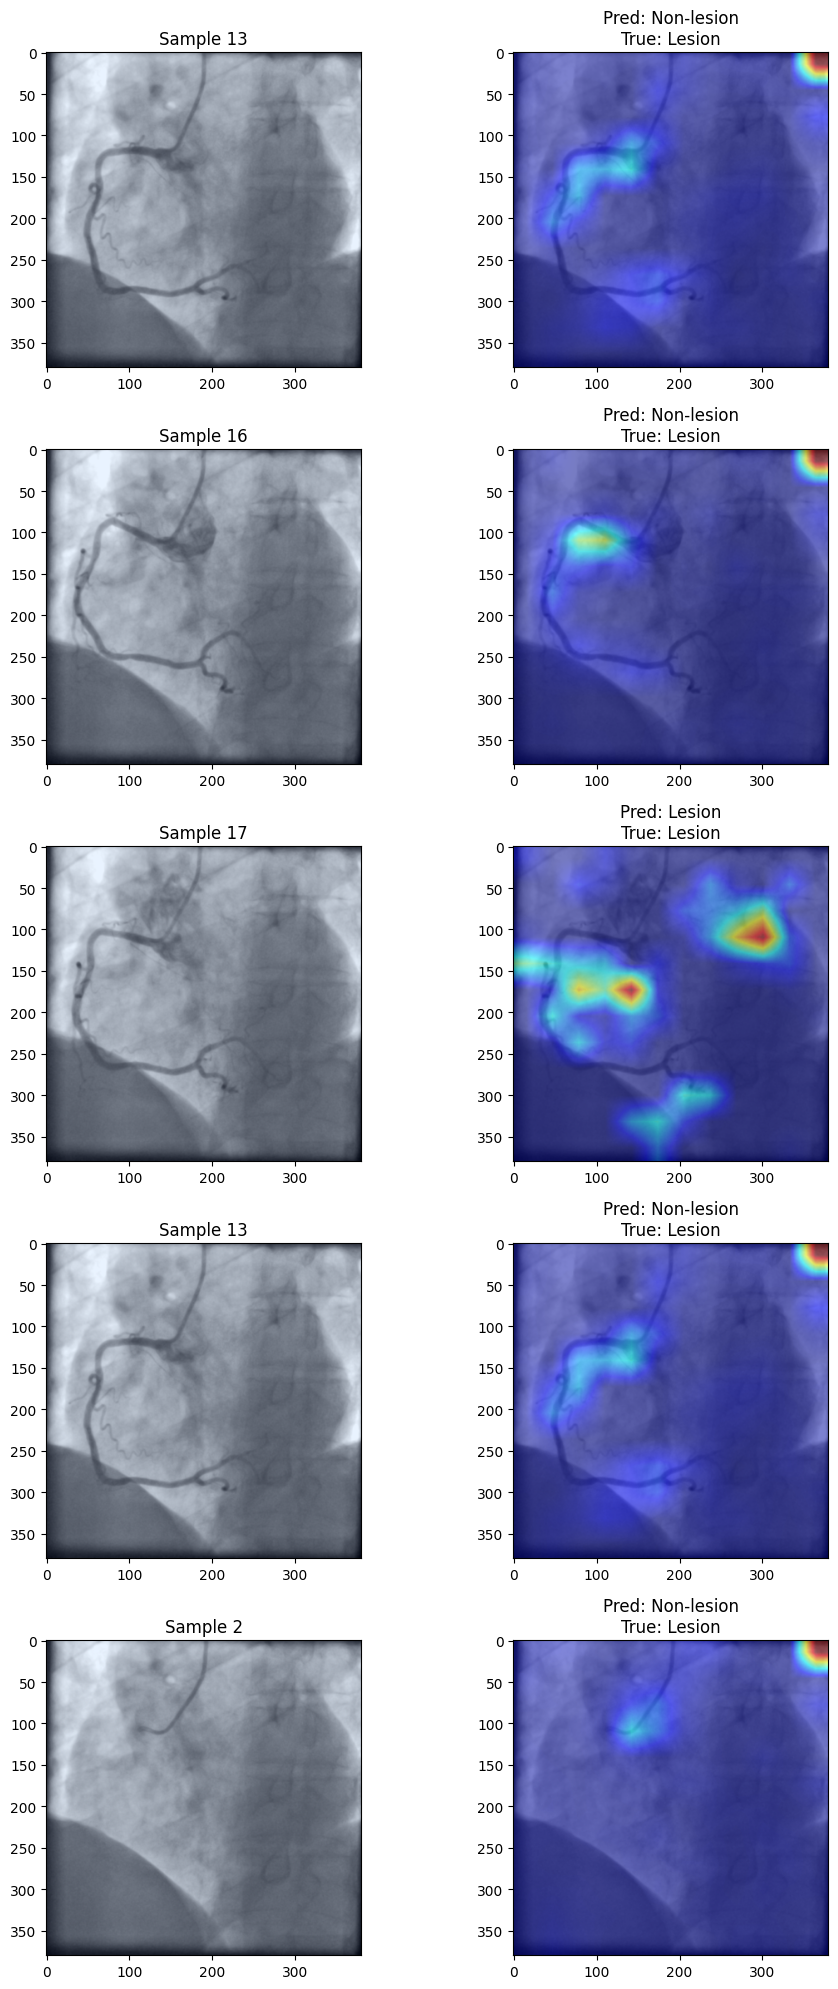

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Grad-CAM 설정 (EfficientNet의 마지막 컨볼루션 레이어 지정)
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 2. 데이터셋에서 배치 가져오기
model.eval()
data_iter = iter(val_loader)
images, labels = next(data_iter) # 이미지와 라벨 2개만 받습니다

fig, axes = plt.subplots(5, 2, figsize=(10, 20))

# 3. 5개 샘플 랜덤 추출 및 시각화
for i in range(5):
    idx = random.randint(0, len(images)-1)
    input_tensor = images[idx:idx+1].to(device)

    # 모델 예측
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

    # 타겟: 예측한 클래스에 대해 Grad-CAM 생성
    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    # 이미지 정규화 및 변환
    img = images[idx].permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    visualization = show_cam_on_image(img, grayscale_cam[0, :], use_rgb=True)

    # 시각화
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Sample {idx}")
    axes[i, 1].imshow(visualization)
    axes[i, 1].set_title(f"Pred: {'Lesion' if pred==1 else 'Non-lesion'}\nTrue: {'Lesion' if labels[idx]==1 else 'Non-lesion'}")

plt.tight_layout()
plt.show()

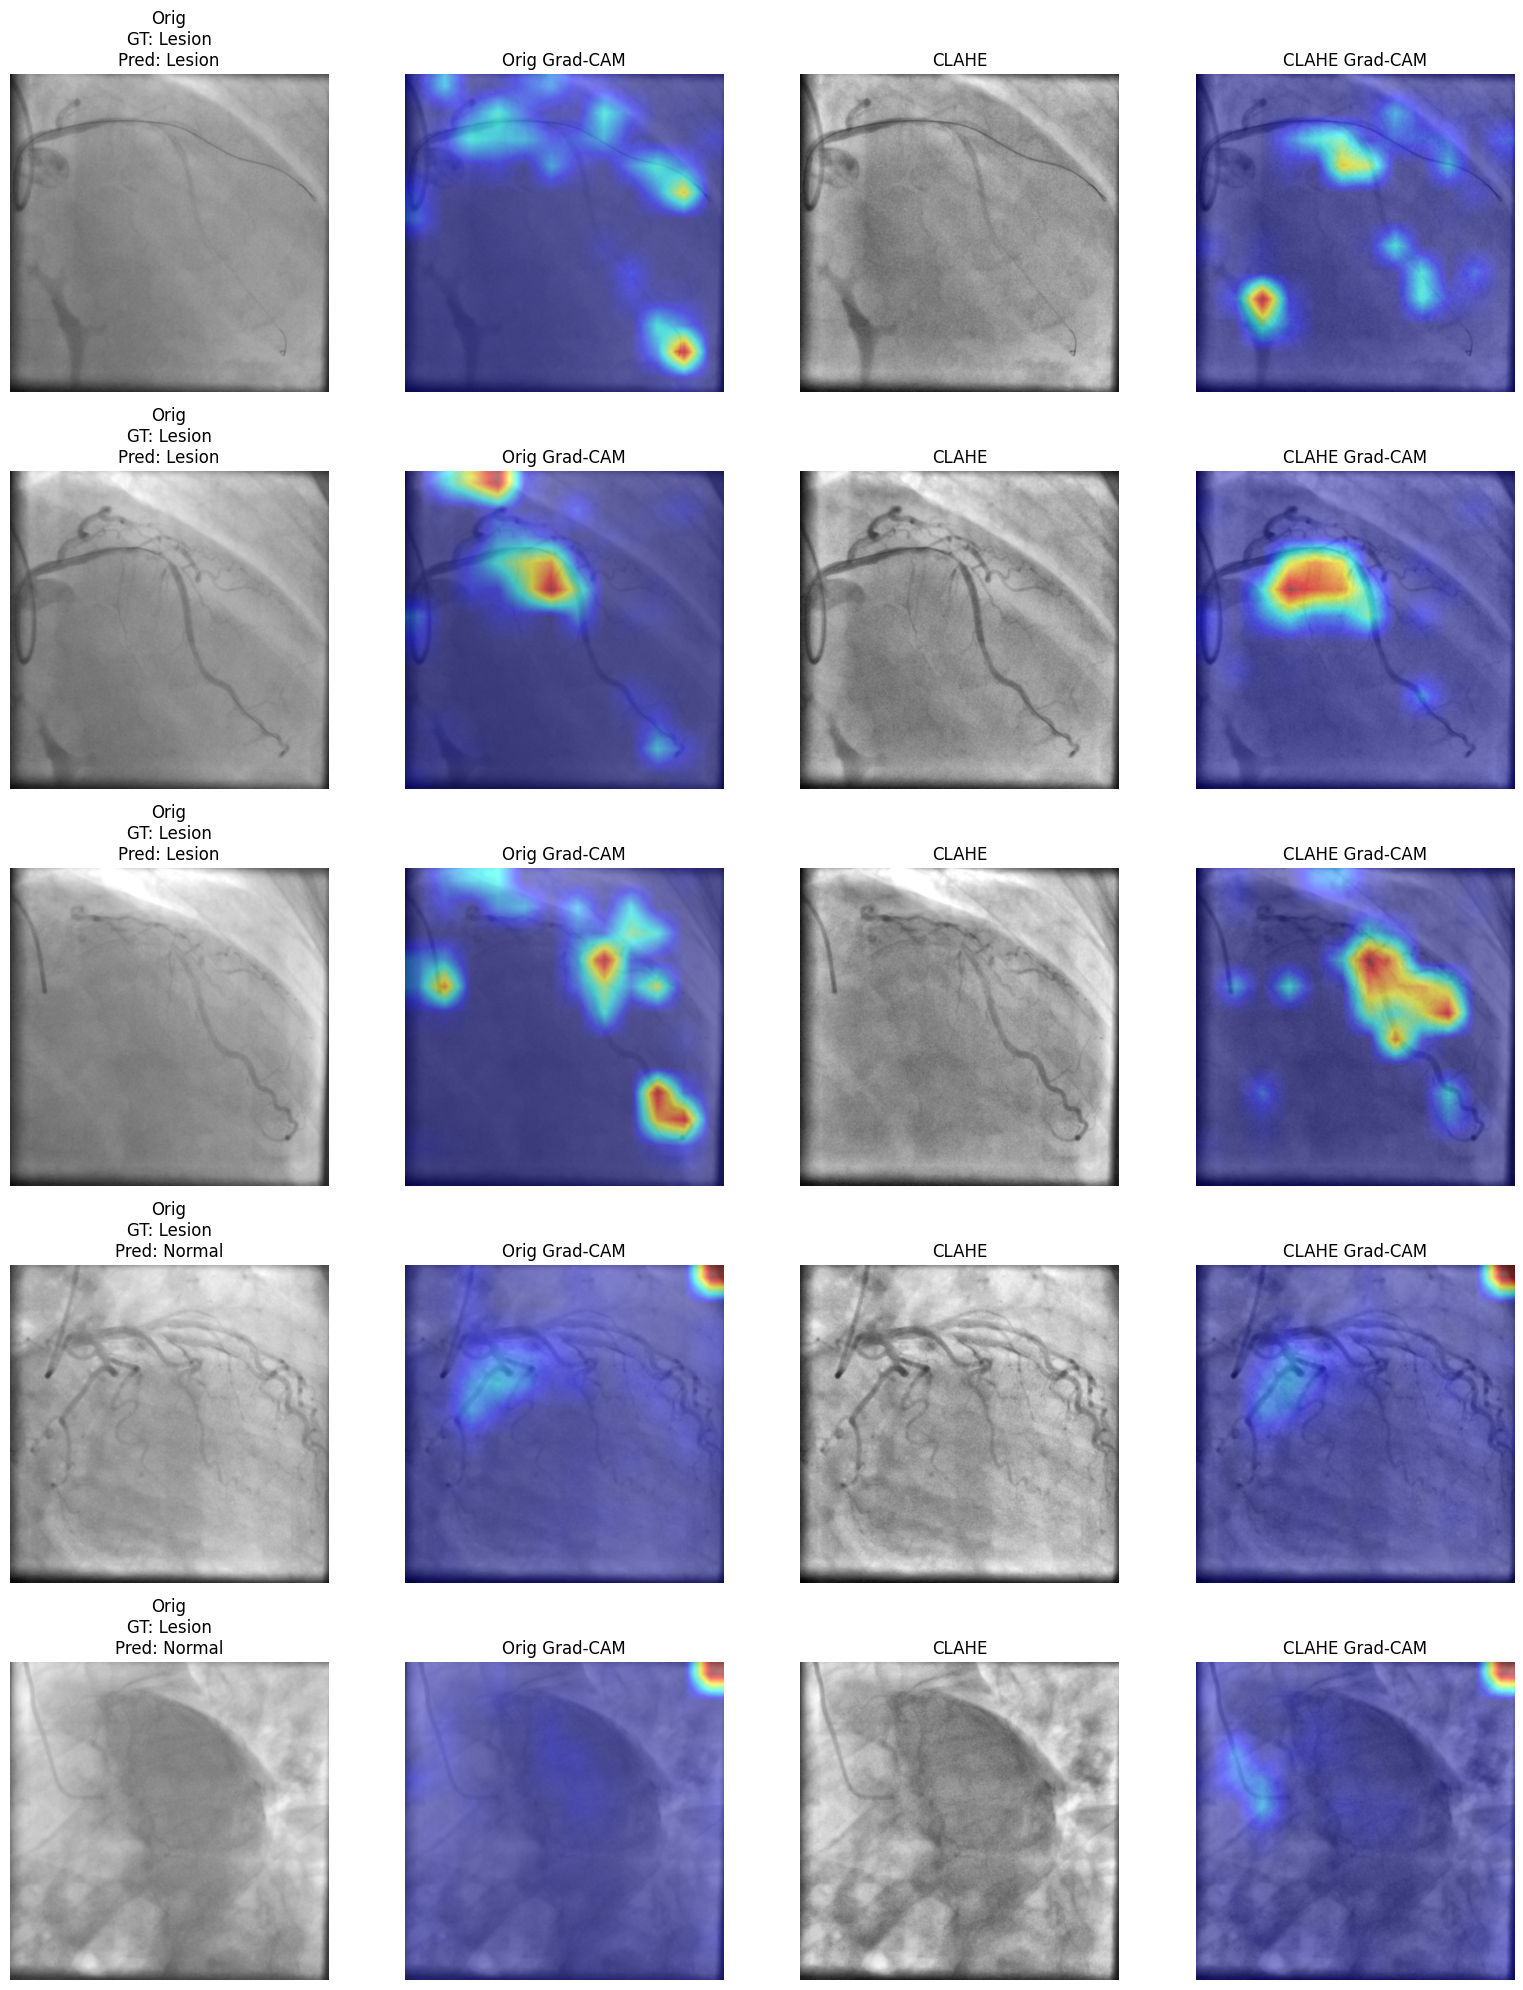

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget # Added for ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. CLAHE 전처리 함수
def apply_clahe(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)
    return cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)

# 2. 모델 및 CAM 설정 (EfficientNet의 마지막 컨볼루션 레이어 지정)
model.eval()
target_layers = [model.features[-1]] # EfficientNet의 마지막 컨볼루션 레이어
cam = GradCAM(model=model, target_layers=target_layers)

# 3. 데이터 샘플링
num_images = 5
samples = val_df.sample(num_images) # `cadica_df_for_finetuning` 대신 `val_df` 사용

fig, axes = plt.subplots(num_images, 4, figsize=(16, 20)) # 6열 대신 4열로 변경

for i, (idx, row) in enumerate(samples.iterrows()):
    path = row['frame_path']

    # 라벨을 숫자로 변환 (CADICADataset의 로직과 동일하게)
    gt_label = 1 if row['label'] == 'lesion' else 0

    # 이미지 로드 및 전처리
    img_orig_pil = Image.open(path).convert('RGB')
    # 이미지 크기를 Grad-CAM 입력 크기(380x380)에 맞게 조정
    img_orig_pil_resized = img_orig_pil.resize((380, 380))
    img_np_orig = np.array(img_orig_pil_resized) / 255.0

    # `my_transform` 대신 `transform_val` 사용. EfficientNet의 권장 입력 크기 380x380 사용
    tensor_orig = transform_val(img_orig_pil).unsqueeze(0).to(device)

    img_clahe = apply_clahe(path)
    img_clahe_pil = Image.fromarray(img_clahe) if img_clahe is not None else img_orig_pil # CLAHE 적용 실패시 원본 사용
    img_np_clahe = np.array(img_clahe_pil.resize((380,380))) / 255.0 # EfficientNet의 권장 입력 크기 380x380 사용
    tensor_clahe = transform_val(img_clahe_pil).unsqueeze(0).to(device)

    # 예측 및 정보 구성
    with torch.no_grad():
        output = model(tensor_orig)
        pred = torch.argmax(output, dim=1).item()
    title_info = f"GT: {'Lesion' if gt_label==1 else 'Normal'}\nPred: {'Lesion' if pred==1 else 'Normal'}"

    # CAM 계산
    # ClassifierOutputTarget을 사용하여 예측된 클래스에 대한 CAM 생성
    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam_orig = cam(input_tensor=tensor_orig, targets=targets)[0, :]
    grayscale_cam_clahe = cam(input_tensor=tensor_clahe, targets=targets)[0, :]

    # 시각화 (4열: 원본, 원본 CAM, CLAHE, CLAHE CAM)
    axes[i, 0].imshow(img_orig_pil_resized) # Resize된 이미지 사용
    axes[i, 0].set_title(f"Orig\n{title_info}")
    axes[i, 1].imshow(show_cam_on_image(img_np_orig, grayscale_cam_orig, use_rgb=True))
    axes[i, 1].set_title("Orig Grad-CAM")

    axes[i, 2].imshow(img_clahe_pil)
    axes[i, 2].set_title("CLAHE")
    axes[i, 3].imshow(show_cam_on_image(img_np_clahe, grayscale_cam_clahe, use_rgb=True))
    axes[i, 3].set_title("CLAHE Grad-CAM")

    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.show()